In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Analisi dei prezzi energetici europei attraverso il mix produttivo

L’aumento dei prezzi dell’energia in Europa ha reso rilevante analizzare come produzione, mix energetico e prezzi siano collegati tra loro. <br>

L'interessa per questo dominio nasce dalla consapevolezza che un modo per evitare sprechi è comprendere quanto costino. <br>

Tramite docenti delle scuole superiori mi è stato trasmesso un pensiero critico su quanto impattano i costi effettivi degli sprechi sulle famiglie.

Le domande a cui si cercherà di dare una risposta sono:
 - Q1: Che relazione esiste tra energia pulita e prezzo dell'elettricità?
 - Q2: Il nucleare è associato a una minore variabilità del prezzo dell’elettricità?
 - Q3: Che relazione esiste tra energia fossile e prezzo dell’elettricità?
 - Q4: Quanto influenzano le importazioni sul prezzo dell’elettricità

# Dati utilizzati

I dati utilizzati provengono da Ember e sono i seguenti:

1. *Yearly Electricity Data* <br>
    Fonte: **Ember – Global Electricity Data** (https://ember-energy.org/data/yearly-electricity-data/) <br>
    Creato da: *[Nicolas Fulghum](https://ember-energy.org/people/nicolas-fulghum/)* <br>
    Dati disponibili: *dal 2000 al 2024* <br>
    Contiene informazioni annuali sulla produzione, capacità, import/export, domanda ed emissioni di energia elettrica per oltre 200 paesi e territori.

3. *European Wholesale Electricity Prices – Monthly* <br>
    Fonte: **Ember – European Wholesale Electricity Price Data** (https://ember-energy.org/data/european-wholesale-electricity-price-data/) <br>
    Creato da: *[Leonard Heberer](https://ember-energy.org/people/leo-heberer/)* <br>
    Dati disponibili: *dal 2015 al 2025* <br>
    Contiene i prezzi mensili all’ingrosso dell’elettricità in Europa (€/MWh), aggregati per paese. <br>

*La mancanza di dati sui costi energetici globali ha limitato l'analisi ai **soli paesi europei.***

I dataset contengono (<span style="color: green; font-weight: bold">verde</span>: dati usati nell'analisi):
1. *Yearly Electricity Data* <br>
    - <span style="color: green; font-weight: bold">Generazione elettrica (TWh)</span>, fornita da tipi di carburanti e aggregati
    - <span style="color: green; font-weight: bold">Importazione elettrica (TWh)</span>
    - <span style="color: green; font-weight: bold">Domada elettrica (TWh)</span>, calcolata come somma dell'elettricità generata e importata
    - Capacità di generazione elettrica (GW), suddivisa per tipo di carburante
    - Emissioni dalla generazione elettrica (Mt CO2e), calcoalta dai fattori di emissione IPCC <br> <br>
      
    Tali dati sono così raggruppati: <br>
   <img src="../images/fuel_types_mapping.png" width="1200">
2. *European Wholesale Electricity Prices – Monthly* <br>
    - <span style="color: green; font-weight: bold">Prezzo all'ingrosso dell'elettricità (EUR/MWhe)</span>

# Analisi — Premessa

L'analisi si svolge in un contesto di forte stress di mercato, i meccanismi di formazione del prezzo potrebbero emergere con maggiore chiarezza rispetto a periodi di stabilità.

Come punto di riferimento è stato preso l'anno 2022:
- **Crisi del gas e prezzi record** [(invasione russa, prezzo europeo fino +300 €/MWh)](https://www.consilium.europa.eu/it/infographics/a-market-mechanism-to-limit-excessive-gas-price-spikes/)
- **Siccità storica** [(mancanza precipitazioni a livello europeo, calo produzione idroelettrica del 21%)](https://www.energiaitalia.news/news/idroelettrico/idroelettrico-produzione-crollata-del-35-nel-2022-il-dato-peggiore-degli-ultimi-10-anni/16632/)
- **Indisponibilità del nucleare** [(manutenzione centrali Francesi, calo produzione da nucleare del 16,7%)](https://www.fondazionesvilupposostenibile.org/calata-nel-2022-la-produzione-nucleare-nella-ue-167/#:~:text=ENERGIA%20E%20CLIMA-,Calata%20nel%202022%20la%20produzione%20nucleare%20nella%20Ue%2C%20%2D16%2C,%2C7%25%20rispetto%20al%202021.)
- **Stress climatico** [(ondate di calore, domanda europea fino +15%)](https://www.i-com.it/2025/07/18/ondate-calore-stress-elettrico-rete/)

# Q1: Che relazione esiste tra energia pulita e prezzo dell'elettricità?
Vogliamo comprendere se a parità di anno, i paesi con maggior quota di produzione di energia pulita hanno prezzi medi dell'elettricità più alta.

Tendenzialmente l'energia pulita presenta delle criticità rispetto alle fonti fossili, prime tra tutte è la programmaticità della produzione stessa, in quanto la produzione green è fortemente influenzata da effetti ambientali.
Per questo motivo ci si apetta che il prezzo dell'elettrictà nei paesi che adottano misure mirate verso l'energia pulita avranno dei prezzi maggiorati.

# Quota energia pulita vs Prezzo elettricità

In [2]:
with open('../data/pickles/dataframe_q1.pickle', 'rb') as handle:
    year, df_y = list(pickle.load(handle).items())[0]

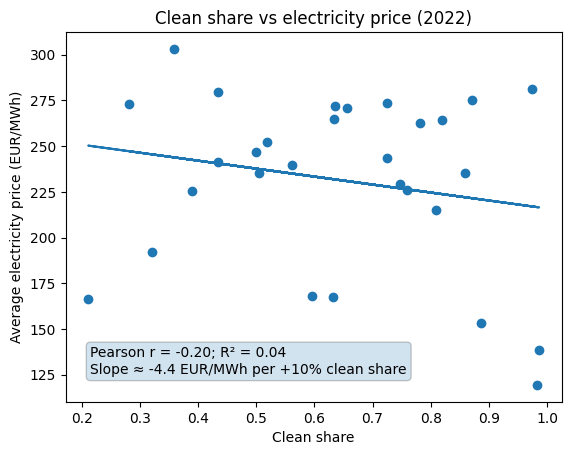

In [3]:
x = df_y["clean_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)
corr = df_y["clean_share"].corr(df_y["AvgPrice_EUR_MWh"])

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Clean share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Clean share vs electricity price ({year})")

plt.annotate(
    f"Pearson r = {corr:.2f}; R² = {corr**2:.2f}\n"
    f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% clean share",
    xy=(0.05, 0.15),
    xycoords="axes fraction",
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.show()

Un'alta quota di energia pulita è associata ad un lieve abbassamento dei prezzi, anche se la relazione è debolemnte negativa (r=-0.20). <br>
Per questo motivo l'analisi viene scomposta in energia rinnovabile e nucleare

# Quota energia rinnovabile vs Prezzo elettricità

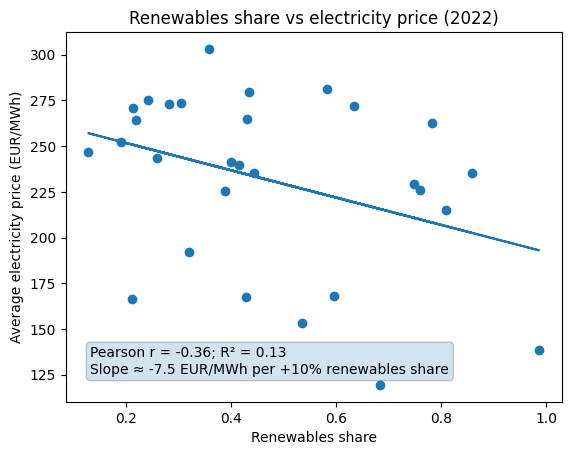

In [4]:
x = df_y["renewables_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)
corr = df_y["renewables_share"].corr(df_y["AvgPrice_EUR_MWh"])

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Renewables share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Renewables share vs electricity price ({year})")

plt.annotate(
    f"Pearson r = {corr:.2f}; R² = {corr**2:.2f}\n"
    f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% renewables share",
    xy=(0.05, 0.15),
    xycoords="axes fraction",
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.show()

Un'alta quota di rinnovabili è associata ad una moderata riduzione dei prezzi: la relazione è moderatamente negativa (r= -0.36).

# Quota energia nucleare vs Prezzo elettricità

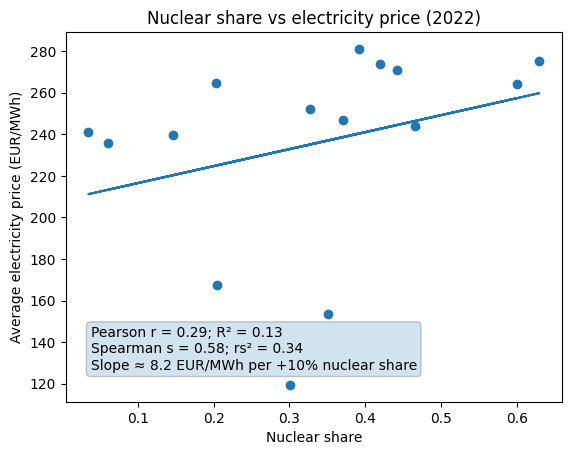

In [5]:
with_nuclear = df_y[df_y["Has_Nuclear"]]

x = with_nuclear["nuclear_share"]
y = with_nuclear["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)
corr_p = with_nuclear["nuclear_share"].corr(with_nuclear["AvgPrice_EUR_MWh"])
corr_s = with_nuclear["nuclear_share"].corr(with_nuclear["AvgPrice_EUR_MWh"], method="spearman")

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Nuclear share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Nuclear share vs electricity price ({year})")

plt.annotate(
    f"Pearson r = {corr_p:.2f}; R² = {corr**2:.2f}\nSpearman s = {corr_s:.2f}; rs² = {corr_s**2:.2f}\n"
    f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% nuclear share",
    xy=(0.05, 0.205),
    xycoords="axes fraction",
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.show()

Un'alta quota di energia prodotta dal nucleare è associata ad un moderato innalzamento dei prezzi: la relazione è debolmente positiva per Pearson (r = 0.29), ma è moderatamente positiva per Spearman (s = 0.58)

# Limite dell'analisi
Lo share di una fonte sul totale della produzione nazionale non garantisce che tale fonte determini il prezzo dell’elettricità.

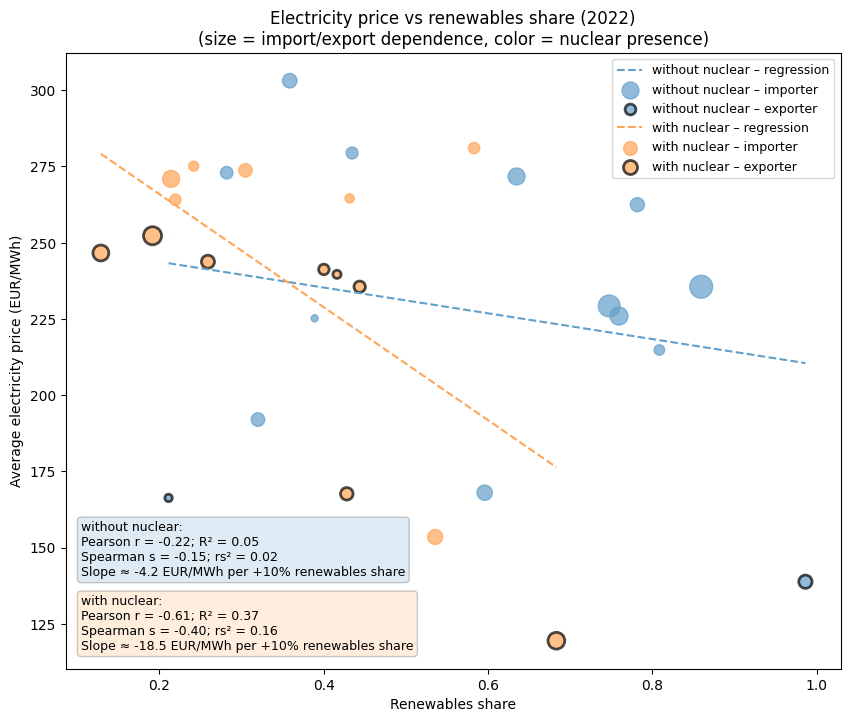

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, (label, g) in enumerate(df_y.groupby("Has_Nuclear")):
    label_str = "with nuclear" if label else "without nuclear"
    color = "#ffa556" if label else "#629fca"

    # regressione
    x = g["renewables_share"]
    y = g["AvgPrice_EUR_MWh"]
    
    m, q = np.polyfit(x, y, 1)

    regression_x = [min(x), max(x)]
    regression_y = [m*_x + q for _x in regression_x]
    
    ax.plot(
        regression_x,
        regression_y,
        color=color,
        linestyle="--",
        linewidth=1.5,
        label=f"{label_str} – regression",
    )

    # scatter punti
    imp = g[g["is_importer"]]
    ax.scatter(
        imp["renewables_share"],
        imp["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(imp["import_share"]),
        alpha=0.7,
        color=color,
        label=f"{label_str} – importer",
    )

    exp = g[~g["is_importer"]]
    ax.scatter(
        exp["renewables_share"],
        exp["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(exp["import_share"]),
        alpha=0.7,
        edgecolors="black",
        linewidth=2,
        facecolors=color,
        label=f"{label_str} – exporter",
    )

    corr_p = g["renewables_share"].corr(g["AvgPrice_EUR_MWh"])
    corr_s = g["renewables_share"].corr(g["AvgPrice_EUR_MWh"], method="spearman")

    ax.annotate(
        f"{label_str}:\n"
        f"Pearson r = {corr_p:.2f}; R² = {corr_p**2:.2f}\nSpearman s = {corr_s:.2f}; rs² = {corr_s**2:.2f}\n"
        f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% renewables share",
        xy=(0.02, 0.24 - i*0.12), 
        xycoords="axes fraction",
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", alpha=0.2, facecolor=color)
    )

ax.set_xlabel("Renewables share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title(
    f"Electricity price vs renewables share ({year})\n"
    "(size = import/export dependence, color = nuclear presence)"
)

ax.legend(fontsize=9)
plt.show()

Il grafico mostra che:
- una quota elevata di energia rinnovabile non implica necessariamente prezzi medi dell’elettricità più bassi. <br>
- le nazioni che principalmente importano corrente hanno tendenzialmene prezzi più alti.<br>
- il nucleare sembra implichi una variabilità di prezzo minore.<br>

# Q2: Il nucleare è associato a una minore variabilità del prezzo dell’elettricità?

L’obiettivo è valutare se la presenza del nucleare sia associata a una minore variabilità o a una diversa dispersione dei prezzi.

In [7]:
with open('../data/pickles/dataframe_q2.pickle', 'rb') as handle:
    year, df_y = list(pickle.load(handle).items())[0]

In [8]:
with_nuclear = df_y[df_y["Has_Nuclear"]]
without_nuclear = df_y[~df_y["Has_Nuclear"]]

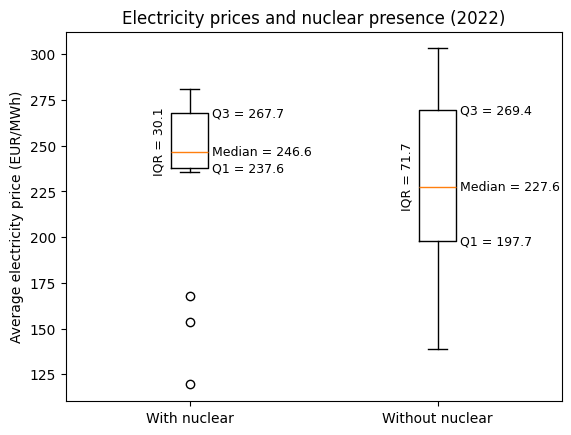

In [9]:
plt.figure()

data = [
    with_nuclear["AvgPrice_EUR_MWh"],
    without_nuclear["AvgPrice_EUR_MWh"]
]

labels = ["With nuclear", "Without nuclear"]

plt.boxplot(data, tick_labels=labels)

plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Electricity prices and nuclear presence ({year})")

# Calcolo quantili
stats = [
    (
        d.quantile(0.25),
        d.median(),
        d.quantile(0.75)
    )
    for d in data
]

# Annotazioni
for i, (q1, med, q3) in enumerate(stats, start=1):
    iqr = q3 - q1

    plt.text(i + 0.09, q1, f"Q1 = {q1:.1f}", va="center", fontsize=9)
    plt.text(i + 0.09, med, f"Median = {med:.1f}", va="center", fontsize=9)
    plt.text(i + 0.09, q3, f"Q3 = {q3:.1f}", va="center", fontsize=9)
    plt.text(i - 0.15, q1 + iqr/2, f"IQR = {iqr:.1f}", ha="left", va="center", fontsize=9, rotation =90)

plt.show()

Nei paesi con nucleare i prezzi risultano concentrati in un intervallo più ristretto, suggerisce un effetto di stabilizzazione.

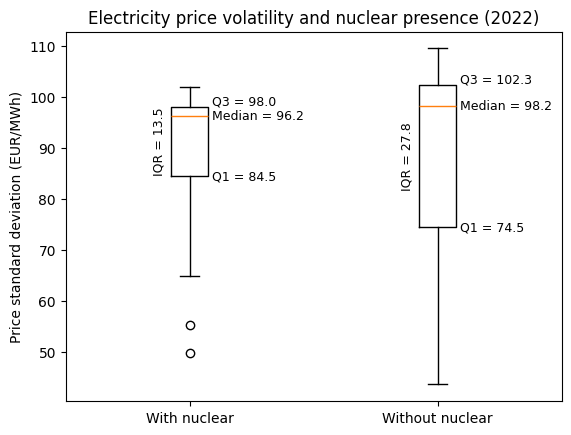

In [10]:
plt.figure()

data = [
    with_nuclear["StdPrice_EUR_MWh"],
    without_nuclear["StdPrice_EUR_MWh"]
]

labels = ["With nuclear", "Without nuclear"]

plt.boxplot(data, tick_labels=labels)

plt.ylabel("Price standard deviation (EUR/MWh)")
plt.title(f"Electricity price volatility and nuclear presence ({year})")

# Calcolo quantili
stats = [
    (
        d.quantile(0.25),
        d.median(),
        d.quantile(0.75)
    )
    for d in data
]

# Annotazioni
for i, (q1, med, q3) in enumerate(stats, start=1):
    iqr = q3 - q1

    plt.text(i + 0.09, q1, f"Q1 = {q1:.1f}", va="center", fontsize=9)
    plt.text(i + 0.09, med, f"Median = {med:.1f}", va="center", fontsize=9)
    plt.text(i + 0.09, q3 + 1, f"Q3 = {q3:.1f}", va="center", fontsize=9)
    plt.text(i - 0.15, q1 + iqr/2, f"IQR = {iqr:.1f}", ha="left", va="center", fontsize=9, rotation =90)



plt.show()


La volatilità dei prezzi nelle nazioni con nucleare è moderatamente inferiore rispetto a quella delle nazioni senza nucleare, suggerendo una prevedibilità maggiore.

# Q3: Relazione tra energia fossile e prezzo dell’elettricità

Si vuole comprendere se a parità di anno, i paesi con maggior quota di produzione di energia fossile hanno prezzi medi dell'elettricità più bassa.

Essendo il carbone, il gas e altri fossili delle fonti programmabili, ci si aspetta generalmente che i prezzi energetici calino all'aumentare dello share fossile, ma siccome l'anno 2022 è stato fortemente influenzato da fattori globali, come fattori geopolitici, infrastrutturali e naturali, questo binomio potrebbe fortemente risentirne.

In [11]:
with open('../data/pickles/dataframe_q3.pickle', 'rb') as handle:
    year, df_y = list(pickle.load(handle).items())[0]

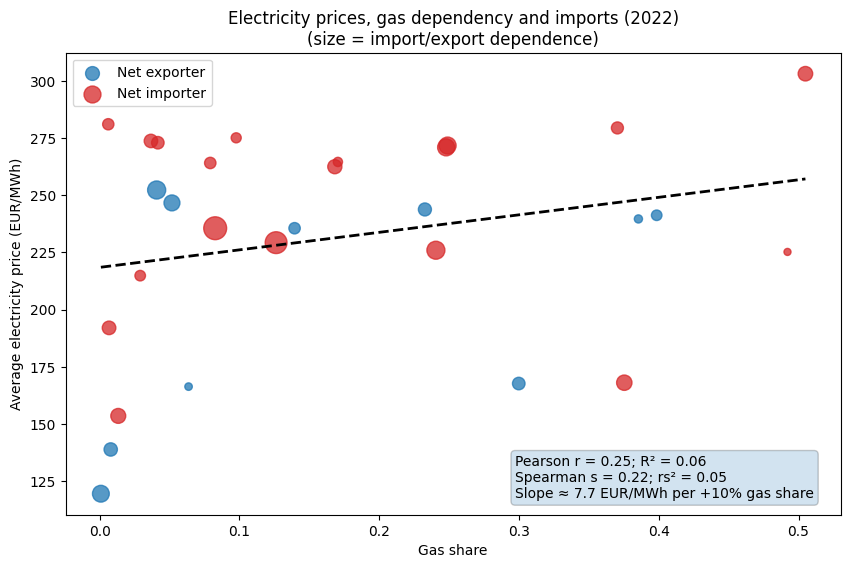

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {True: "#d62728", False: "#1f77b4"}
labels = {True: "Net importer", False: "Net exporter"}

for is_imp, g in df_y.groupby("is_importer"):
    ax.scatter(
        g["gas_share"],
        g["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(g["import_share"]),
        alpha=0.75,
        color=colors[is_imp],
        label=labels[is_imp],
    )

x = df_y["gas_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)

regression_x = [min(x), max(x)]
regression_y = [m*_x + q for _x in regression_x]

ax.plot(regression_x, regression_y, color="black", linestyle="--", linewidth=2)

corr_p = df_y["gas_share"].corr(df_y["AvgPrice_EUR_MWh"])
corr_s = df_y["gas_share"].corr(df_y["AvgPrice_EUR_MWh"], method="spearman")

plt.annotate(
    f"Pearson r = {corr_p:.2f}; R² = {corr_p**2:.2f}\nSpearman s = {corr_s:.2f}; rs² = {corr_s**2:.2f}\n"
    f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% gas share",
    xy=(0.58, 0.13),
    xycoords="axes fraction",
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

ax.set_xlabel("Gas share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title(
    "Electricity prices, gas dependency and imports (2022)\n"
    "(size = import/export dependence)"
)

ax.legend()
plt.show()

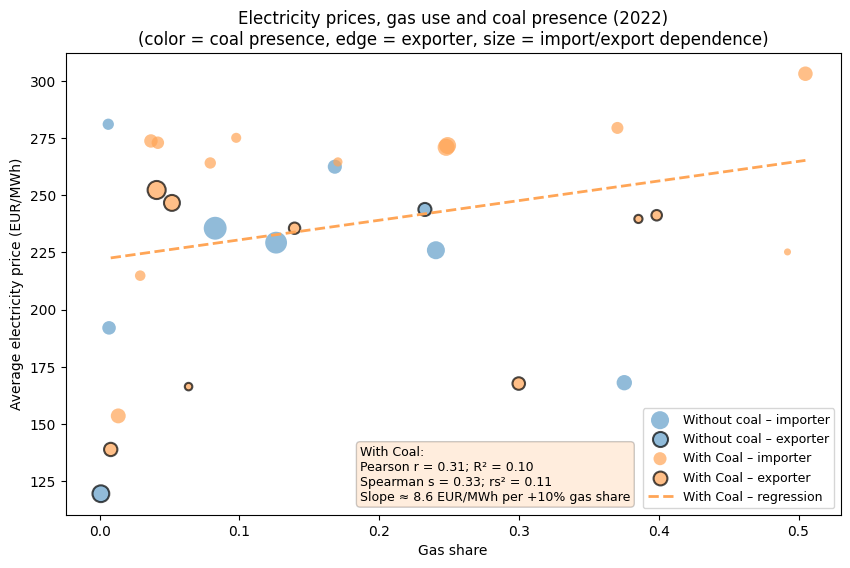

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {True: "#ffa556", False: "#629fca"}
labels = {True: "With Coal", False: "Without coal"}

handles = []  # per la legenda
legend_labels = []

for i, (label, g) in enumerate(df_y.groupby("Has_coal")):
    color = colors[label]
    group_name = labels[label]

    # scatter punti
    imp = g[g["is_importer"]]
    exp = g[~g["is_importer"]]

    sc_imp = ax.scatter(
        imp["gas_share"],
        imp["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(imp["import_share"]),
        alpha=0.7,
        color=color,
        edgecolors="none"
    )
    sc_exp = ax.scatter(
        exp["gas_share"],
        exp["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(exp["import_share"]),
        alpha=0.7,
        edgecolors="black",
        linewidth=1.5,
        facecolors=color
    )

    handles.extend([sc_imp, sc_exp])
    legend_labels.extend([f"{group_name} – importer", f"{group_name} – exporter"])

    # regressione
    x = g["gas_share"]
    y = g["AvgPrice_EUR_MWh"]
    
    corr_p = g["gas_share"].corr(g["AvgPrice_EUR_MWh"])
    corr_s = g["gas_share"].corr(g["AvgPrice_EUR_MWh"], method="spearman")

    if abs(corr_p) >= 0.05:
        m, q = np.polyfit(x, y, 1)
        
        regression_x = [min(x), max(x)]
        regression_y = [m*_x + q for _x in regression_x]
        reg_line, = ax.plot(
            regression_x,
            regression_y,
            linestyle="--",
            linewidth=2,
            color=color
        )
        handles.append(reg_line)
        legend_labels.append(f"{group_name} – regression")

        # annotazioni
        ax.annotate(
            f"{group_name}:\n"
            f"Pearson r = {corr_p:.2f}; R² = {corr_p**2:.2f}\nSpearman s = {corr_s:.2f}; rs² = {corr_s**2:.2f}\n"
            f"Slope ≈ {m*0.10:.1f} EUR/MWh per +10% gas share",
            xy=(0.38, 0.28 - i*0.13),
            xycoords="axes fraction",
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", alpha=0.2, facecolor=color)
        )

ax.set_xlabel("Gas share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title(
    "Electricity prices, gas use and coal presence (2022)\n"
    "(color = coal presence, edge = exporter, size = import/export dependence)"
)

ax.legend(handles=handles, labels=legend_labels, fontsize=9)
plt.show()